In [1]:
import hoda
import tensorly as tl
tl.get_backend()

'cupy'

In [2]:
from moabb.paradigms import P300
from moabb.datasets import *

tmin = 0
tmax=0.8
fmin=0.5
fmax = 16
sfreq = 32

paradigm = P300(resample=sfreq, tmin=tmin, tmax=tmax, fmin=fmin, fmax=fmax)
dataset = BNCI2014_009()
epochs, labels, meta = paradigm.get_data(dataset=dataset, 
                                         subjects=[1],
                                         return_epochs=True)
session = meta['session'][0]
idc = meta['session'] == session
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]

<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_types is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_channels_regexp is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.channel_type is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
/usr/local/lib/python3.10/dist-packages/moabb/pipelines/__init__.py:26: ModuleNotFoundError: Tensorflow is not installed. You won't be able to use these MOABB pipelines if you attempt to do so.
  warn(


To use the get_shape_from_baseconcar, InputShapeSetterEEG, BraindecodeDatasetLoaderyou need to install `braindecode`.`pip install braindecode` or Please refer to `https://braindecode.org`.
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
1728 matching events found
No baseline correction applied


/usr/local/lib/python3.10/dist-packages/moabb/paradigms/base.py:354: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  X = mne.concatenate_epochs(X)


In [3]:
epochs

Number of events,576
Events,NonTarget: 480Target: 96
Time range,0.000 – 0.781 s
Baseline,off


In [4]:
meta

,subject,session,run
0,1,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,1,0,0
...,...,...,...
571,1,0,0
572,1,0,0
573,1,0,0
574,1,0,0


In [5]:
X = epochs.get_data()
y = labels

X.shape

/tmp/ipykernel_2156/2444922706.py:1: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  X = epochs.get_data()


(576, 16, 26)

In [6]:
from hoda.hoda import HODA, f_multiway
from hoda.gpu_opt import center
import warnings

from hoda.hoda import f_oneway, mode_scatter
from hoda.gpu_opt import center, ledoit_wolf_shrinkage, combine_pvalues
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from hoda.classification import Vectorize
from sklearn.feature_selection import SelectFwe
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import pandas as pd
from sklearn.preprocessing import StandardScaler


hoda = HODA(
            rank=2,
            max_iter=256,
            tol=1e-8,
            init ='svd',
            shrinkage=0,
            toeplitz=(1,),
            obj='rt',
            solver='lanczos',
            taper=False,
            keep_train_info=True,
            verbose=True,
        )

%lprun -f HODA.fit hoda.fit(X,y)
hoda

Initializing factors...
Fitting discriminative Tucker model...


  0%|          | 0/256 [00:00<?, ?it/s]

Fitted Tucker model of rank (2, 2) ...


HODA(keep_train_info=True, rank=2, shrinkage=0, toeplitz=(1,), verbose=True)

Timer unit: 1e-09 s

Total time: 2.5567 s
File: /project/src/hoda/hoda.py
Function: fit at line 298

Line #      Hits         Time  Per Hit   % Time  Line Contents
   298                                               def fit(self, X, y):
   299                                                   # Setup
   300                                                   # X = tl.tensor(X.copy(), dtype=X.dtype)
   301         1   75967369.0    8e+07      3.0          X = tl.tensor(X, dtype=X.dtype)
   302         1     123975.0 123975.0      0.0          self.classes_, class_counts = np.unique(y, return_counts=True)
   303         1     803204.0 803204.0      0.0          class_counts = tl.tensor(class_counts)
   304         1       3914.0   3914.0      0.0          n_samples, *shape = X.shape
   305         1        503.0    503.0      0.0          order = len(shape)
   306                                           
   307                                                   # Initialize solver
   308

In [7]:
hoda.train_info_

,F_tr,F_rt,mse,update
iteration,,,,
0.0,0.185621,0.002791,2.158045e-11,1.053253e-01
1.0,0.453095,0.005165,1.984191e-11,9.716705e-02
2.0,0.514338,0.007071,2.127311e-11,1.904939e-02
3.0,0.571646,0.006870,2.083052e-11,9.485952e-03
4.0,0.550811,0.007281,2.117353e-11,2.750730e-03
5.0,0.567962,0.007147,2.104603e-11,1.005765e-03
6.0,0.558359,0.007234,2.113781e-11,2.354428e-04
7.0,0.564950,0.007192,2.109957e-11,1.096337e-04
8.0,0.561503,0.007212,2.112647e-11,2.249479e-05


/tmp/ipykernel_2156/2077482890.py:10: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  axs[2].set_ylim([0,None])


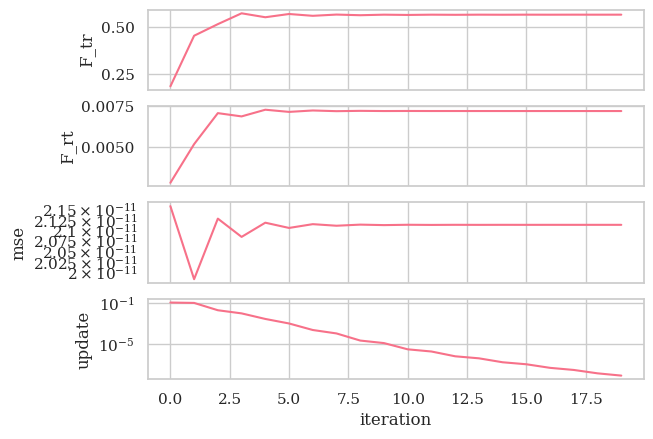

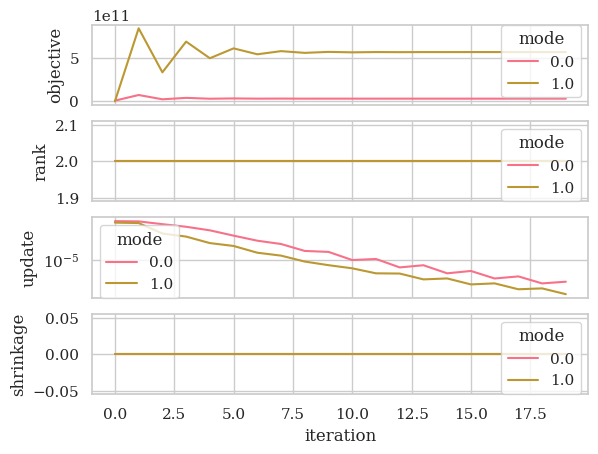

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

if hoda.keep_train_info:
    fig, axs = plt.subplots(4,1, sharex=True)
    sns.lineplot(data=hoda.train_info_.astype(float), x='iteration', y='F_tr', ax=axs[0])
    sns.lineplot(data=hoda.train_info_.astype(float), x='iteration', y='F_rt', ax=axs[1])
    sns.lineplot(data=hoda.train_info_.astype(float), x='iteration', y='mse', ax=axs[2])
    axs[2].set(yscale="log")
    axs[2].set_ylim([0,None])
    sns.lineplot(data=hoda.train_info_.astype(float), x='iteration', y='update', ax=axs[3])
    axs[3].set(yscale="log")


    fig, axs = plt.subplots(4,1, sharex=True)
    sns.lineplot(data=hoda.mode_train_info_.astype(float), x='iteration', y='objective',hue='mode', ax=axs[0])
    sns.lineplot(data=hoda.mode_train_info_.astype(float), x='iteration', y='rank',hue='mode', ax=axs[1])
    sns.lineplot(data=hoda.mode_train_info_.astype(float), x='iteration', y='update',hue='mode', ax=axs[2])
    axs[2].set(yscale="log")
    sns.lineplot(data=hoda.mode_train_info_.astype(float), x='iteration', y='shrinkage',hue='mode', ax=axs[3])


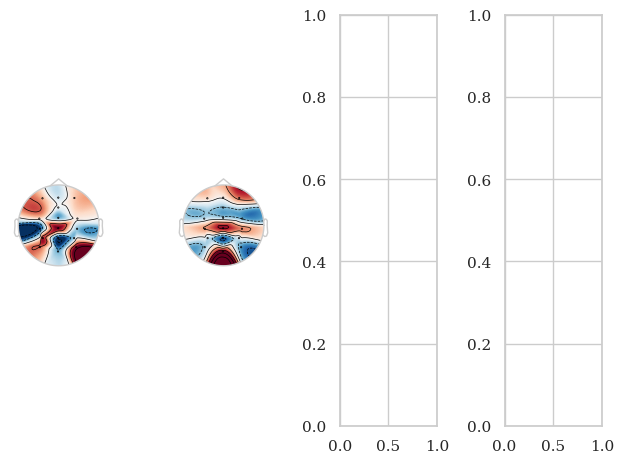

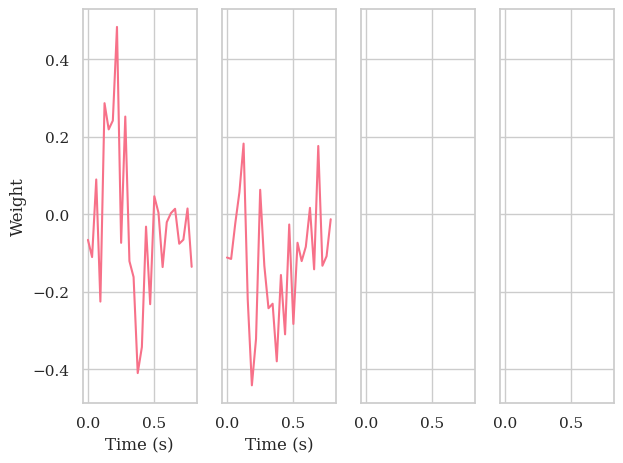

In [9]:

import numpy as np
from mne.viz import plot_topomap
import matplotlib.pyplot as plt
import tensorly as tl


col_wrap = 4

n_col = col_wrap
n_row = int( np.ceil(hoda.rank_(0) / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
for i in range(hoda.rank_(0)):
    w = tl.to_numpy(hoda.scalings_[0][:,i])
    plot_topomap(w, epochs.info, axes=axs.flatten()[i], show=False)

n_row = int( np.ceil(hoda.rank_(1) / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col,  layout='tight', sharex=True, sharey=True)
for i in range(hoda.rank_(1)):
    w = tl.to_numpy(hoda.scalings_[1][:,i])
    axs.flatten()[i].plot(epochs.times, w)
    axs.flatten()[i].set_xlabel('Time (s)')
    axs.flatten()[i].sharey(axs.flatten()[0])
axs.flatten()[0].set_ylabel('Weight');


In [10]:
"""
n_row = int(np.ceil(hoda.rank_(0) / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
A = hoda.aps_[0]
for i in range(hoda.rank_(0)):
    a = tl.to_numpy(A[:,i])
    plot_topomap(a, epochs.info, axes=axs.flatten()[i], show=False)


n_row = int(np.ceil(hoda.rank_(1) / col_wrap)) 
fig, axs = plt.subplots(
    n_row, n_col, 
    layout='tight', 
    sharex=True,
    sharey=True
)
A = hoda.aps_[1]
for i in range(hoda.rank_(1)):
    a = tl.to_numpy(A[:,i])
    axs.flatten()[i].plot(epochs.times, a)
    axs.flatten()[i].set_xlabel('Time (s)')
    axs.flatten()[i].sharey(axs.flatten()[0])
axs.flatten()[0].set_ylabel('Amplitude');
"""

"\nn_row = int(np.ceil(hoda.rank_(0) / col_wrap)) \nfig, axs = plt.subplots(n_row, n_col, layout='tight')\nA = hoda.aps_[0]\nfor i in range(hoda.rank_(0)):\n    a = tl.to_numpy(A[:,i])\n    plot_topomap(a, epochs.info, axes=axs.flatten()[i], show=False)\n\n\nn_row = int(np.ceil(hoda.rank_(1) / col_wrap)) \nfig, axs = plt.subplots(\n    n_row, n_col, \n    layout='tight', \n    sharex=True,\n    sharey=True\n)\nA = hoda.aps_[1]\nfor i in range(hoda.rank_(1)):\n    a = tl.to_numpy(A[:,i])\n    axs.flatten()[i].plot(epochs.times, a)\n    axs.flatten()[i].set_xlabel('Time (s)')\n    axs.flatten()[i].sharey(axs.flatten()[0])\naxs.flatten()[0].set_ylabel('Amplitude');\n"

In [11]:
"""
_, axs = plt.subplots(2,4, layout='constrained', figsize=(14,8))
for k in range(2):
    
    scatter_b = tl.to_numpy(hoda.scatter_b_[k])
    vmax = np.max(np.abs(scatter_b))
    axs[k,0].set_aspect('equal')
    sns.heatmap(scatter_b, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[k,0])    
    
    scatter_w = tl.to_numpy(hoda.scatter_w_[k])
    vmax = np.max(np.abs(scatter_w))
    sns.heatmap(scatter_w, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[k,1])    
    axs[k,1].set_aspect('equal')


    cov_l= tl.to_numpy(hoda.cov_l_[k])
    vmax = np.max(np.abs(cov_l))
    sns.heatmap(cov_l, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[k,2])    
    axs[k,2].set_aspect('equal')


    cov =  tl.to_numpy(hoda.cov_[k])
    vmax = np.max(np.abs(cov))
    sns.heatmap(cov, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[k,3])    
    axs[k,3].set_aspect('equal')

"""

"\n_, axs = plt.subplots(2,4, layout='constrained', figsize=(14,8))\nfor k in range(2):\n    \n    scatter_b = tl.to_numpy(hoda.scatter_b_[k])\n    vmax = np.max(np.abs(scatter_b))\n    axs[k,0].set_aspect('equal')\n    sns.heatmap(scatter_b, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[k,0])    \n    \n    scatter_w = tl.to_numpy(hoda.scatter_w_[k])\n    vmax = np.max(np.abs(scatter_w))\n    sns.heatmap(scatter_w, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[k,1])    \n    axs[k,1].set_aspect('equal')\n\n\n    cov_l= tl.to_numpy(hoda.cov_l_[k])\n    vmax = np.max(np.abs(cov_l))\n    sns.heatmap(cov_l, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[k,2])    \n    axs[k,2].set_aspect('equal')\n\n\n    cov =  tl.to_numpy(hoda.cov_[k])\n    vmax = np.max(np.abs(cov))\n    sns.heatmap(cov, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[k,3])    \n    axs[k,3].set_aspect('equal')\n\n"

In [12]:
Xt = hoda.transform(X)
Xt

array([[[-2.41388169e-07, -7.65174509e-09],
        [ 1.77352222e-06, -1.23309608e-06]],

       [[ 1.07768291e-07,  8.54606825e-07],
        [-9.29424883e-07,  1.33247261e-07]],

       [[-3.28611485e-06,  6.27578853e-08],
        [ 2.43505945e-06, -1.41102272e-09]],

       ...,

       [[ 2.07617194e-07,  1.17287515e-06],
        [ 3.40846726e-06,  2.82441496e-08]],

       [[-3.01856585e-08, -5.78893686e-07],
        [-1.55576380e-06,  7.38938122e-07]],

       [[ 8.31372908e-07,  6.13057243e-07],
        [ 9.73164546e-07, -6.53685334e-07]]])

[[8.95025465e-07 5.51945386e-49]
 [7.25602129e-69 1.15606193e-01]]

[8.39073650e-06 3.33374989e-51]

[1.19097167e-16 2.40400945e-33]


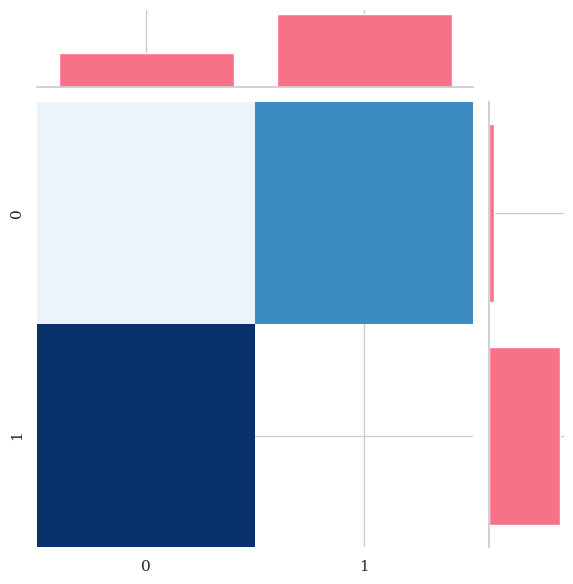

In [13]:
from hoda.hoda import f_multiway
from hoda.gpu_opt import combine_pvalues

F, p = f_oneway(Xt,y)

classes = np.unique(y)
y_like_Xt = tl.zeros_like(Xt)
for ci, c in enumerate(classes):
    y_like_Xt[y==c] = ci


F_sp, p_sp = f_oneway(tl.unfold(Xt, 0+1).T, tl.unfold(y_like_Xt, 0+1).T[:,0])
F_tmp, p_tmp = f_oneway(tl.unfold(Xt, 1+1).T, tl.unfold(y_like_Xt, 1+1).T[:,0])


F_sp = tl.to_numpy(F_sp)
F_tmp = tl.to_numpy(F_tmp)
F = tl.to_numpy(F)
p= tl.to_numpy(p)

g = sns.JointGrid()
sns.heatmap(F, vmin=0, ax=g.ax_joint, mask=p>0.05/p.size,cbar=False, cmap='Blues')
g.ax_marg_x.bar(np.arange(p.shape[1]) + 0.5, F_tmp)
g.ax_marg_y.barh(np.arange(p.shape[0]) + 0.5, F_sp)

print(p)
print()
print(p_sp)
print()
print(p_tmp)

In [14]:
from sklearn.feature_selection import SelectFwe

Xt_flat = tl.to_numpy(Xt.reshape((Xt.shape[0], -1)))
Xt_flat.shape

(576, 4)

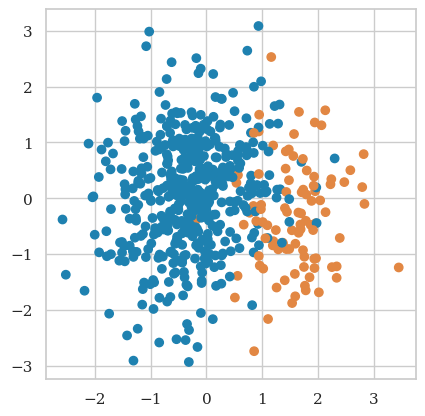

In [15]:

from sklearn.manifold import TSNE
import math
from sklearn.decomposition import PCA
import re, seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import ListedColormap

Xt_flat = tl.to_numpy(Xt.reshape((Xt.shape[0], -1)))

if Xt_flat.shape[-1] > 1:
    n_components = 2
    decomp  = PCA(n_components=n_components, whiten=True)
    Xt_viz = decomp.fit_transform(tl.to_numpy(Xt_flat))
    
    cmap = {'Target': '#e28743', 'NonTarget': '#1e81b0'}
    c = np.vectorize(cmap.get)(y)    
    fig, ax = plt.subplots(1,1)
    ax.scatter(Xt_viz[:,0], Xt_viz[:,1], c=c)
    ax.set_aspect('equal')

No projector specified for this dataset. Please consider the method self.add_proj.


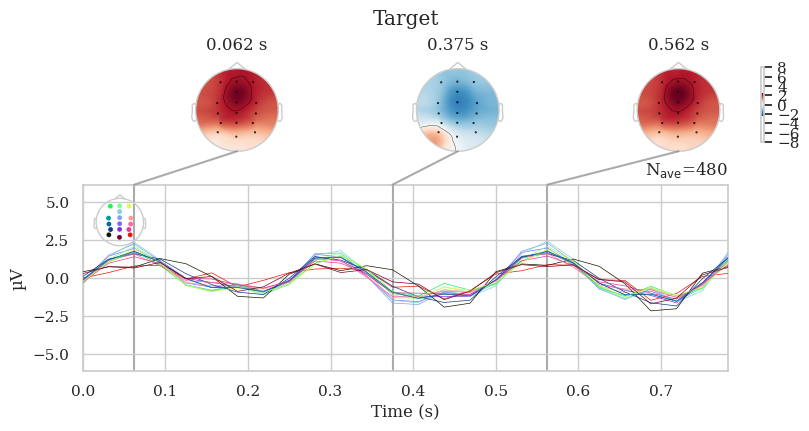

No projector specified for this dataset. Please consider the method self.add_proj.


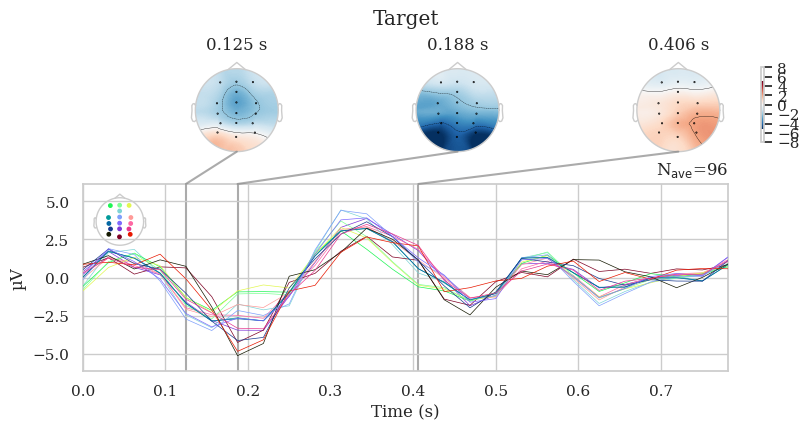

In [16]:
import numpy as np

evokeds = []
vmax=0
for cls in np.unique(labels):
    evoked = epochs[cls].average()
    evokeds.append(evoked)
    vmax= max(vmax, np.max(np.abs(evoked.data))*1.2*1e6)

ts_args=dict(ylim=dict(eeg=[-vmax,vmax]))
joint_args=dict(ts_args=ts_args)

for evoked  in evokeds:
    if len(evoked.ch_names) > 1:
        evoked.plot_joint(title=cls, **joint_args)
    else:
        evoked.plot(**ts_args)

No projector specified for this dataset. Please consider the method self.add_proj.


/tmp/ipykernel_2156/2414566788.py:2: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  epochs_rec._data = tl.to_numpy(hoda.inv_transform(hoda.transform(epochs.get_data())))


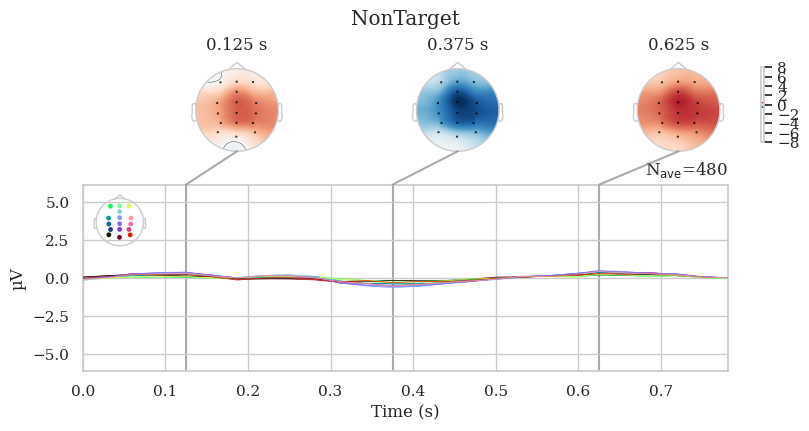

No projector specified for this dataset. Please consider the method self.add_proj.


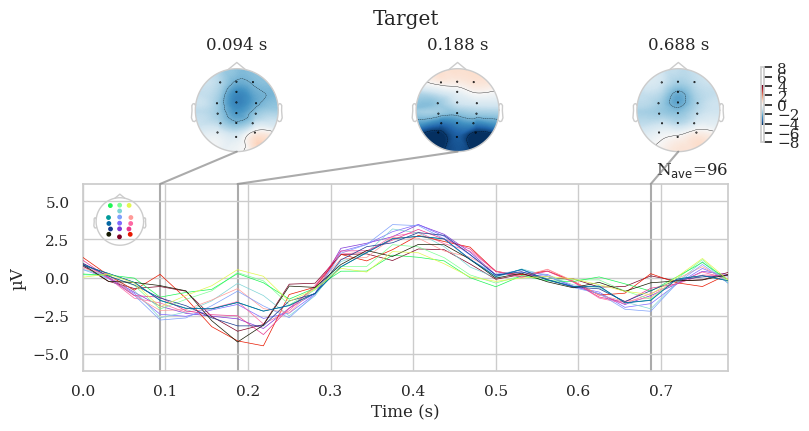

In [17]:
epochs_rec = epochs.copy()
epochs_rec._data = tl.to_numpy(hoda.inv_transform(hoda.transform(epochs.get_data())))
evokeds_rec = []
for cls in np.unique(labels):
    evoked_rec = epochs_rec[cls].average()
    evokeds_rec.append(evoked_rec)
    if len(evoked_rec.ch_names) > 1:
        evoked_rec.plot_joint(title=cls, **joint_args)
    else:
        evoked_rec.plot(**ts_args)

No projector specified for this dataset. Please consider the method self.add_proj.


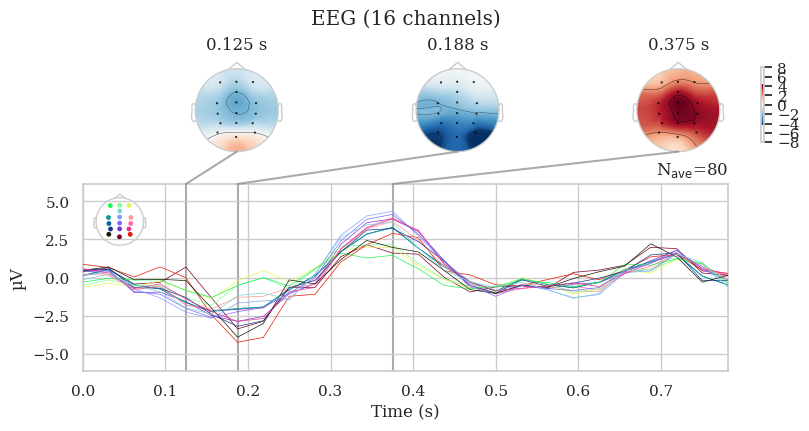

No projector specified for this dataset. Please consider the method self.add_proj.


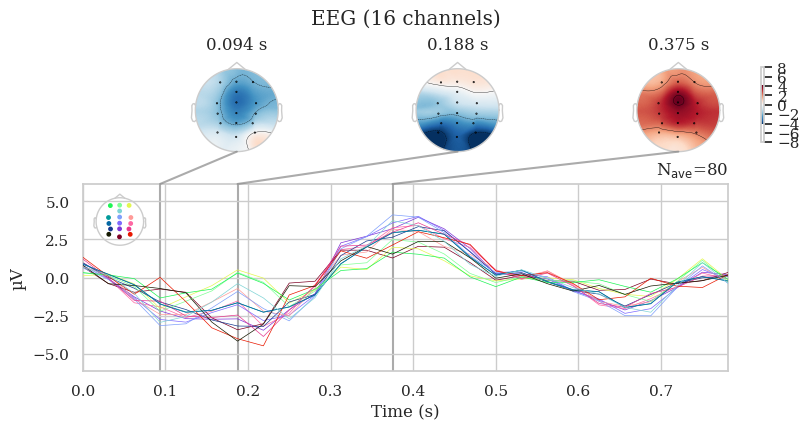

In [18]:
from mne import combine_evoked
contrast = combine_evoked(evokeds, weights=[-1,1])
_ = contrast.plot_joint(**joint_args)
contrast_rec = combine_evoked(evokeds_rec, weights=[-1,1])
_ = contrast_rec.plot_joint(**joint_args)


No projector specified for this dataset. Please consider the method self.add_proj.


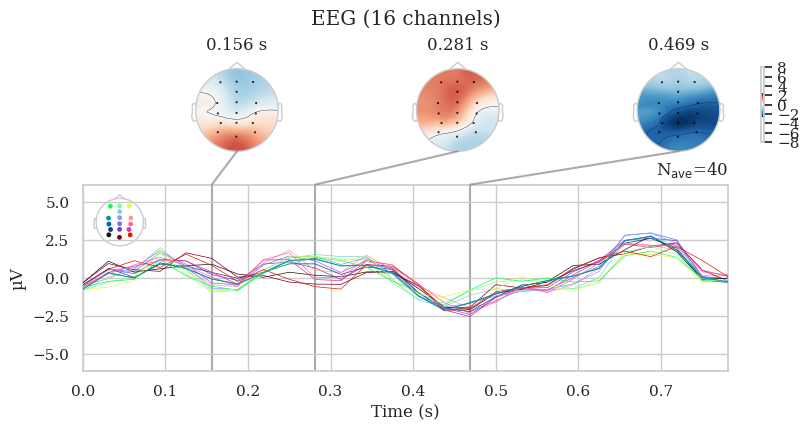

In [19]:
rec_diff = combine_evoked([contrast, contrast_rec], weights=[1,-1])
_ = rec_diff.plot_joint(**joint_args)